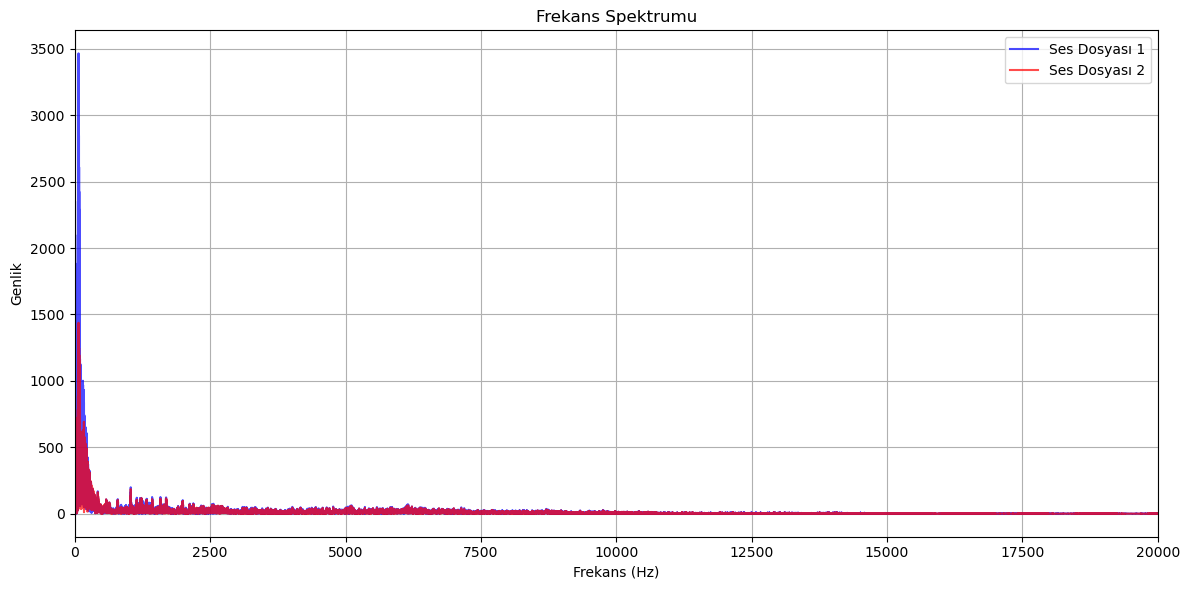

In [2]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import numpy as np # Sayısal hesaplamaları
import librosa # Ses yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# FFT (Hızlı Fourier Dönüşümü) ile frekans spektrumunu hesaplama
def compute_fft(signal, sr):
    fft = np.fft.fft(signal) # Fourier dönüşümünü uygulama
    magnitude = np.abs(fft[:len(fft)//2]) # Sadece pozitif frekans bileşenlerini alma
    freqs = np.fft.fftfreq(len(fft), 1/sr)[:len(fft)//2] # Frekans eksenini oluşturma
    return freqs, magnitude

# Her iki ses için frekans spektrumunu hesaplama
freqs1, mag1 = compute_fft(wave_1, sr_1) # Birinci sesin spektrumu
freqs2, mag2 = compute_fft(wave_2, sr_2) # İkinci sesin spektrumu

# Grafik oluşturma
plt.figure(figsize=(12, 6)) # Grafik boyutunu belirleme

# Frekans spektrumlarının çizimi
plt.plot(freqs1, mag1, label="Ses Dosyası 1", color="blue", alpha=0.7) # Birinci sesin mavi olarak çizimi ve isimlendirme
plt.plot(freqs2, mag2, label="Ses Dosyası 2", color="red", alpha=0.7) # Birinci sesin mavi olarak çizimi ve isimlendirme

# Grafik başlığı ve etiketleri
plt.title("Frekans Spektrumu") # Başlık
plt.xlabel("Frekans (Hz)") # X ekseni etiketi
plt.ylabel("Genlik") # Y ekseni etiketi
plt.legend() # Açıklama kutusu
plt.grid(True) # Grafik ızgara çizgileri
plt.xlim(0, 20000) # Görüntülenen frekans aralığını sınırlama
plt.tight_layout() # Grafik içeriğini sıkılaştırma
plt.show() # Grafiği ekranda gösterme


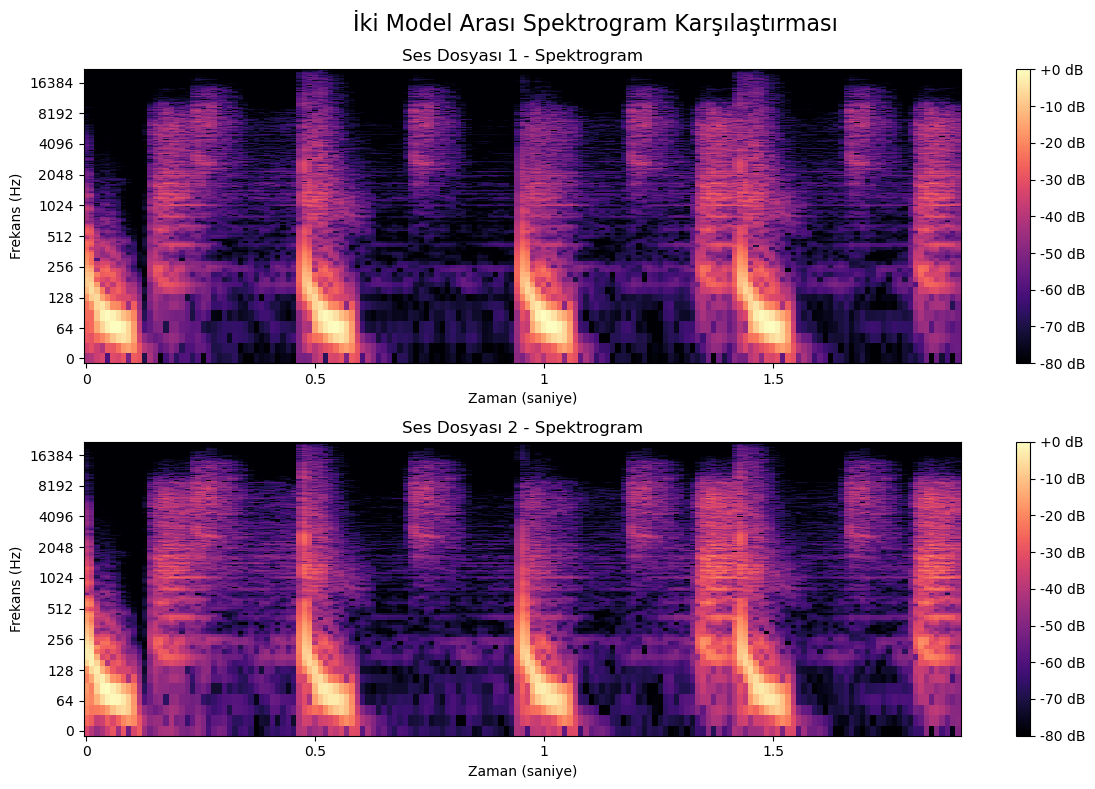

In [4]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import numpy as np # Sayısal hesaplamaları
import librosa # Ses yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# STFT (Short-Time Fourier Transform) parametreleri
n_fft = 2048 # FFT pencere boyutu (frekans çözünürlüğünü belirler)
hop_length = 512 # Her analiz adımında kaydırılan örnek sayısı (zaman çözünürlüğünü etkiler)
cmap = 'magma' # Spektrogram için renk skalası (görsel kontrast sağlar)

# Grafik oluşturma
plt.figure(figsize=(12, 8)) # Grafik alanının boyutlarını belirler

# Birinci ses dosyasının analizi
y1, sr1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükle (orijinal örnekleme oranıyla)
D1 = librosa.stft(y1, n_fft=n_fft, hop_length=hop_length, window='hann') # STFT hesapla (zamana bağlı frekans bileşenlerini elde eder)
S_db1 = librosa.amplitude_to_db(np.abs(D1), ref=np.max) # Genlik değerlerini dB cinsine çevirerek spektrogram için uygun hale getir

# İkinci ses dosyasının analizi
y2, sr2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükle (orijinal örnekleme oranıyla)
D2 = librosa.stft(y2, n_fft=n_fft, hop_length=hop_length, window='hann') # İkinci sesin STFT hesapla
S_db2 = librosa.amplitude_to_db(np.abs(D2), ref=np.max) # Genlik değerlerini dB'ye dönüştür

# Birinci spektrogram grafiği
plt.subplot(2, 1, 1) # 2 satırlı 1 sütunlu yapıda birinci grafiği hazırla
librosa.display.specshow(S_db1, sr=sr1, hop_length=hop_length, x_axis='time', y_axis='log', cmap=cmap) # Birinci spektrogramı çizer
plt.colorbar(format='%+2.0f dB') # Renk skalasını ekle
plt.title(f"{label_1} - Spektrogram") # Birinci grafiğin başlığı
plt.xlabel("Zaman (saniye)") # X ekseni etiketi
plt.ylabel("Frekans (Hz)") # Y ekseni etiketi

# İkinci spektrogram grafiği
plt.subplot(2, 1, 2) # 2 satırlı 1 sütunlu yapıda ikinci grafiği hazırla
librosa.display.specshow(S_db2, sr=sr2, hop_length=hop_length, x_axis='time', y_axis='log', cmap=cmap) # İkinci spektrogramı çizer
plt.colorbar(format='%+2.0f dB') # Renk skalasını ekle
plt.title(f"{label_2} - Spektrogram") # İkinci grafiğin başlığı
plt.xlabel("Zaman (saniye)") # X ekseni etiketi
plt.ylabel("Frekans (Hz)") # Y ekseni etiketi

# Genel başlık ve gösterim
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Alt grafikler arası boşlukları düzenler, üst başlık için yer bırakır
plt.suptitle("İki Model Arası Spektrogram Karşılaştırması", fontsize=16) # Ana başlığı tanımlar
plt.show()  # Grafikleri ekranda gösterir


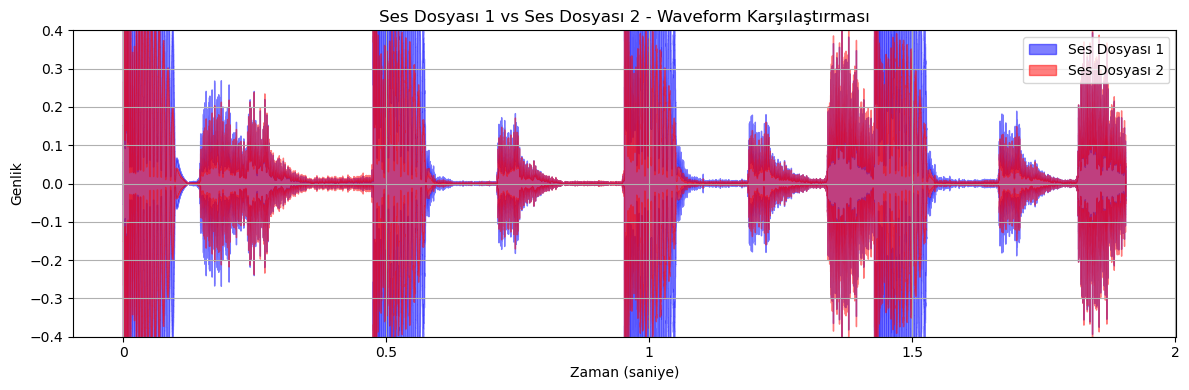

In [6]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import librosa # Ses dosyası yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# Grafik çizimi
plt.figure(figsize=(12, 4)) # Grafik boyutunu ayarlama
librosa.display.waveshow(wave_1, sr=sr_1, alpha=0.5, color='blue', label=label_1) # İlk ses dalgasının çizimi
librosa.display.waveshow(wave_2, sr=sr_2, alpha=0.5, color='red', label=label_2) # İkinci ses dalgasının çizimi

# Başlık, eksenler ve diğer ayarlar
plt.title(f"{label_1} vs {label_2} - Waveform Karşılaştırması") # Grafik başlığı
plt.xlabel("Zaman (saniye)") # X ekseni etiketi
plt.ylabel("Genlik") # Y ekseni etiketi
plt.ylim((-0.4, 0.4)) # Y ekseni için görünüm sınırlarını ayarlama (yakınlaştırma)
plt.legend(loc="upper right") # Grafik etiketi konumu
plt.grid(True) # Grafik ızgara çizgilerini gösterme
plt.tight_layout() # Öğeler arası boşluğu otomatik ayarlama
plt.show() # Grafiği ekranda gösterme


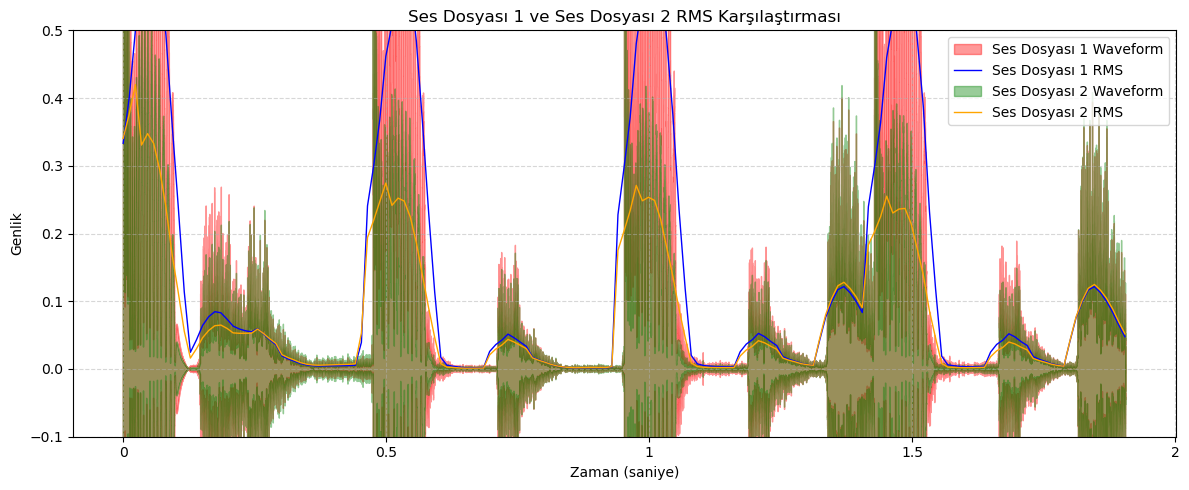

In [8]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import numpy as np # Sayısal hesaplamalar için numpy kütüphanesi
import librosa # Ses yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# RMS (Root Mean Square) hesaplama fonksiyonu
# Bu fonksiyon RMS değerlerini ve zaman bilgilerini döner
def compute_rms(sound, sr, frame_length=2048, hop_length=512):
    rms = librosa.feature.rms(y=sound, frame_length=frame_length, hop_length=hop_length)[0] # RMS değerlerini hesaplama
    time = librosa.times_like(rms, sr=sr, hop_length=hop_length) # Zaman ekseni oluşturma
    return rms, time

# Ses dosyalarını yükle
sound_1, sr_1 = librosa.load(file_1, sr=None) # İlk ses dosyasını yükleme
sound_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# RMS değerlerini hesapla
rms_1, time_1 = compute_rms(sound_1, sr_1) # İlk ses dosyası için RMS hesaplama
rms_2, time_2 = compute_rms(sound_2, sr_2) # İkinci ses dosyası için RMS hesaplama

# Grafik oluştur
plt.figure(figsize=(12, 5)) # Grafik boyutunu ayarlama

# İki sinyali ve RMS grafiklerini aynı eksende çizme
librosa.display.waveshow(sound_1, sr=sr_1, alpha=0.4, color='red', label=f"{label_1} Waveform") # Birinci ses dalgası
plt.plot(time_1, rms_1, color="blue", linewidth=1, label=f"{label_1} RMS") # Birinci RMS eğrisi

librosa.display.waveshow(sound_2, sr=sr_2, alpha=0.4, color='green', label=f"{label_2} Waveform") # İkinci ses dalgası
plt.plot(time_2, rms_2, color="orange", linewidth=1, label=f"{label_2} RMS") # İkinci RMS eğrisi

plt.title(f"{label_1} ve {label_2} RMS Karşılaştırması") # Grafik başlığı
plt.xlabel("Zaman (saniye)") # X ekseni etiketi
plt.ylabel("Genlik") # Y ekseni etiketi
plt.ylim((-0.1, 0.5)) # Y ekseni sınırları
plt.legend(fontsize=10, loc="upper right") # Etiketleri gösterme
plt.grid(True, linestyle='--', alpha=0.5) # Grafik ızgara çizgileri
plt.tight_layout() # Otomatik yerleşim düzenlemesi
plt.show() # Grafiği gösterme


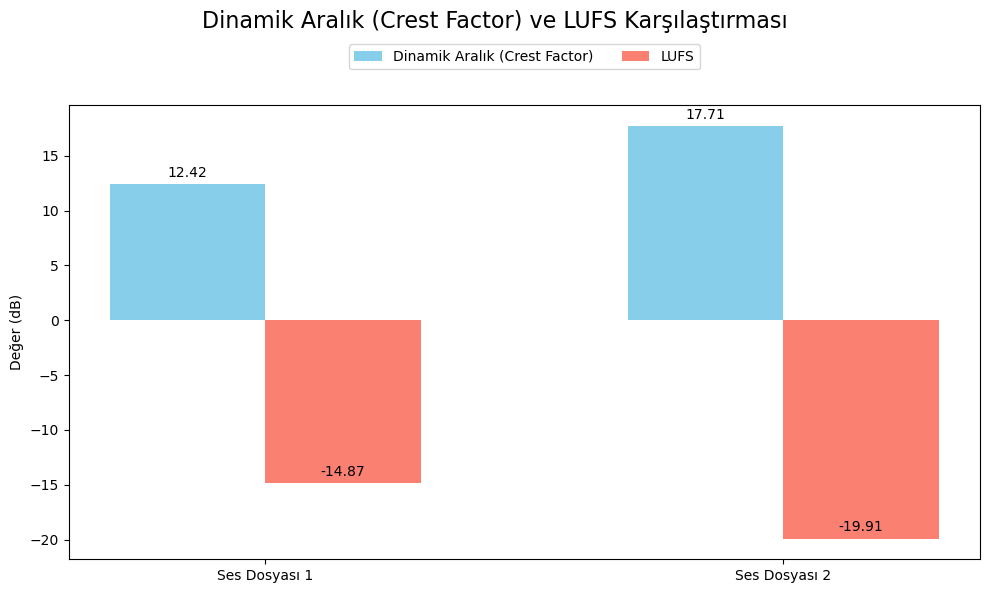

In [10]:
import matplotlib.pyplot as plt # Grafik çizimi için matplotlib kütüphanesi
import numpy as np # Sayısal hesaplamalar için numpy kütüphanesi
import librosa # Ses dosyası yükleme ve işleme için
import pyloudnorm as pyln # LUFS (Loudness Units Full Scale) analizi için

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# LUFS analiz aracı
meter = pyln.Meter(sr_1) # LUFS ölçer (örnekleme oranı dosyanın orijinal değeriyle uyumlu)

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükle (orijinal örnekleme oranıyla)
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükle (orijinal örnekleme oranıyla)

# Dinamik Aralık (Crest Factor) Hesaplama
max_1 = np.max(np.abs(wave_1)) # İlk sesin maksimum genlik değeri
rms_1 = np.sqrt(np.mean(wave_1 ** 2)) # İlk sesin RMS değeri
max_2 = np.max(np.abs(wave_2)) # İkinci sesin maksimum genlik değeri
rms_2 = np.sqrt(np.mean(wave_2 ** 2)) # İkinci sesin RMS değeri

# Crest Factor (Dinamik Aralık) hesapla
cf_1 = 20 * np.log10(max_1 / rms_1) if rms_1 > 0 else -np.inf # İlk ses için dinamik aralık
tcf_2 = 20 * np.log10(max_2 / rms_2) if rms_2 > 0 else -np.inf # İkinci ses için dinamik aralık

# LUFS Hesaplama
lufs_1 = meter.integrated_loudness(wave_1) # İlk sesin LUFS değeri
lufs_2 = meter.integrated_loudness(wave_2) # İkinci sesin LUFS değeri

# Grafik Çizimi
fig, ax = plt.subplots(figsize=(10, 6)) # Grafik figürü oluşturma
x = np.arange(2) # X ekseni konumları
width = 0.3 # Çubuk genişliği

# Çubuk grafiğini çizdirme ve etiketleri ekleme
bar1 = ax.bar(x - width/2, [cf_1, tcf_2], width, label="Dinamik Aralık (Crest Factor)", color='skyblue')  # Dinamik aralık sütunları
bar2 = ax.bar(x + width/2, [lufs_1, lufs_2], width, label="LUFS", color='salmon')  # LUFS sütunları

# Sütunların üzerine değer etiketlerini ekleme
for bars in [bar1, bar2]: # Her sütun grubu için değerler
    for bar in bars:
        height = bar.get_height() # Sütunların yüksekliği
        ax.annotate(f'{height:.2f}', # Sayısal değer
                    xy=(bar.get_x() + bar.get_width() / 2, height), # Etiketin konumu
                    xytext=(0, 3), # Y ekseninden 3 birim yukarı
                    textcoords="offset points", # Konum için birim tipi
                    ha='center', va='bottom') # Hizalama

# Eksen etiketleri ve başlıkları
ax.set_ylabel("Değer (dB)") # Y ekseni etiketi
ticks = [label_1, label_2] # X ekseni etiketleri
ax.set_xticks(x) # X ekseni konumlarını ayarlama
ax.set_xticklabels(ticks) # X ekseni isimlerini uygulama
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2) # Açıklama kutusunu üst merkeze yerleştir

# Grafik düzenini ayarla ve gösterme
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Yerleşimi optimize etme
plt.suptitle("Dinamik Aralık (Crest Factor) ve LUFS Karşılaştırması", fontsize=16) # Başlık
plt.show() # Grafiği gösterme


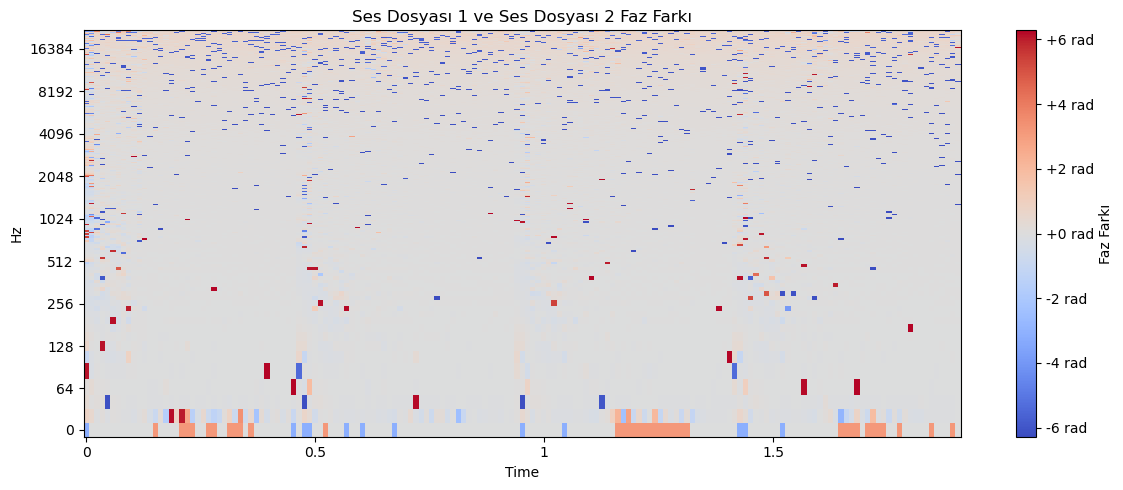

In [12]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import numpy as np # Sayısal hesaplamalar
import librosa # Ses yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# Faz farkını hesaplayıp görselleştirme
def plot_phase_difference(y_ref, sr_ref, y_comp, sr_comp, title):
    S_ref = librosa.stft(y_ref) # Referans sesin STFT işlemi (zamana bağlı frekans bileşenleri)
    S_comp = librosa.stft(y_comp) # Karşılaştırılacak sesin STFT işlemi (zamana bağlı frekans bileşenleri)

    phase_ref = np.angle(S_ref) # Referans sinyalin faz bilgisi (radyan cinsinden)
    phase_comp = np.angle(S_comp) # Karşılaştırılan sinyalin faz bilgisi (radyan cinsinden)
    phase_diff = phase_ref - phase_comp # İki sinyal arasındaki faz farkı hesaplama

    # Faz farkını görselleştirme
    plt.figure(figsize=(12, 5)) # Grafik boyutunu ayarlama
    img = librosa.display.specshow(
        phase_diff, sr=sr_ref, x_axis="time", y_axis="log", cmap="coolwarm"  # Faz farkını zaman-frekans düzleminde renkli olarak gösterme
    )
    plt.title(title) # Grafiğin başlığı
    plt.colorbar(img, format="%+2.0f rad", label="Faz Farkı") # Renk skalası (radyan cinsinden) ve etiket
    plt.tight_layout() # Grafik elemanlarının sıkı yerleşimini sağlama
    plt.show() # Grafiği ekranda gösterirme

# Fonksiyonu çağırarak karşılaştırmayı gerçekleştirme
plot_phase_difference(wave_1, sr_1, wave_2, sr_2, f"{label_1} ve {label_2} Faz Farkı")


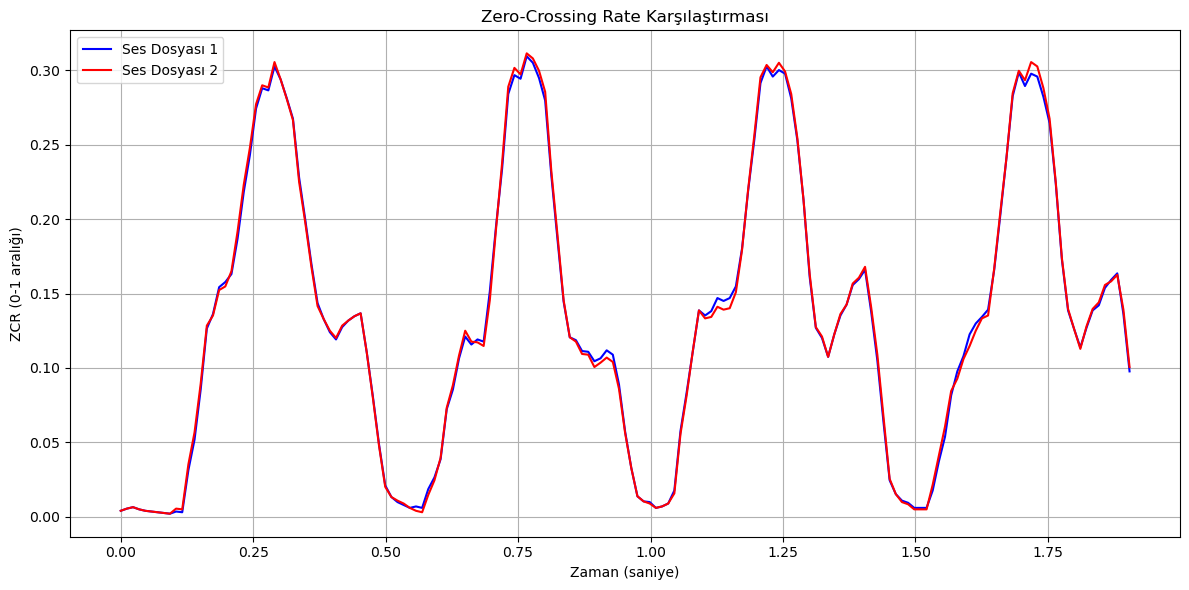

In [14]:
import matplotlib.pyplot as plt  # Grafik çizimleri için kullanılan kütüphane
import librosa # Ses işleme ve analiz için kullanılan popüler Python kütüphanesi
import librosa.display # Librosa'nın ses görselleştirme fonksiyonları

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
# y = ses sinyali (dalga formu), sr = örnekleme hızı (sampling rate)
y1, sr1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
y2, sr2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# Zero-Crossing Rate hesaplama
# Her ses sinyali için ZCR değerini çerçeve bazında hesaplama
zcr1 = librosa.feature.zero_crossing_rate(y1)[0] # Birinci sesin ZCR değeri
zcr2 = librosa.feature.zero_crossing_rate(y2)[0] # İkinci sesin ZCR değeri

# Zaman eksenlerini oluşturma
# ZCR değerlerine karşılık gelen zaman vektörlerini hesaplama
time1 = librosa.times_like(zcr1, sr=sr1)
time2 = librosa.times_like(zcr2, sr=sr2)

# Grafik çizimi
plt.figure(figsize=(12, 6)) # Grafik boyutunu ayarlama
plt.plot(time1, zcr1, label=label_1, color="blue") # İlk sesin ZCR grafiği çizimi
plt.plot(time2, zcr2, label=label_2, color="red") # İkinci sesin ZCR grafiği çizimi

plt.title("Zero-Crossing Rate Karşılaştırması") # Grafik başlığı
plt.xlabel("Zaman (saniye)") # X ekseni etiketi
plt.ylabel("ZCR (0-1 aralığı)") # Y ekseni etiketi
plt.legend() # Etiket kutusunun gösterimi
plt.grid() # Grafiğe ızgara çizgileri ekleme
plt.tight_layout() # Alt alta grafiklerin taşmasını önleme
plt.show() # Grafiği ekranda gösterme
